## Overview
Analyzes ~200 sustainability reports from European steel companies using 
ClimateBERT to extract climate discourse metrics.

## Metrics
- **Volume**: % of report that is climate-related
- **Specificity**: How concrete vs vague the claims are (0-100)
- **Commitment**: How much action-oriented language (0-100)
- **Talk Score**: Compound = 20% volume + 40% specificity + 40% commitment
- **Sentiment**: Opportunity / Neutral / Risk framing

✅ Loaded: 193 reports, 15 companies, 2013-2024
   ✓ slide_main.png


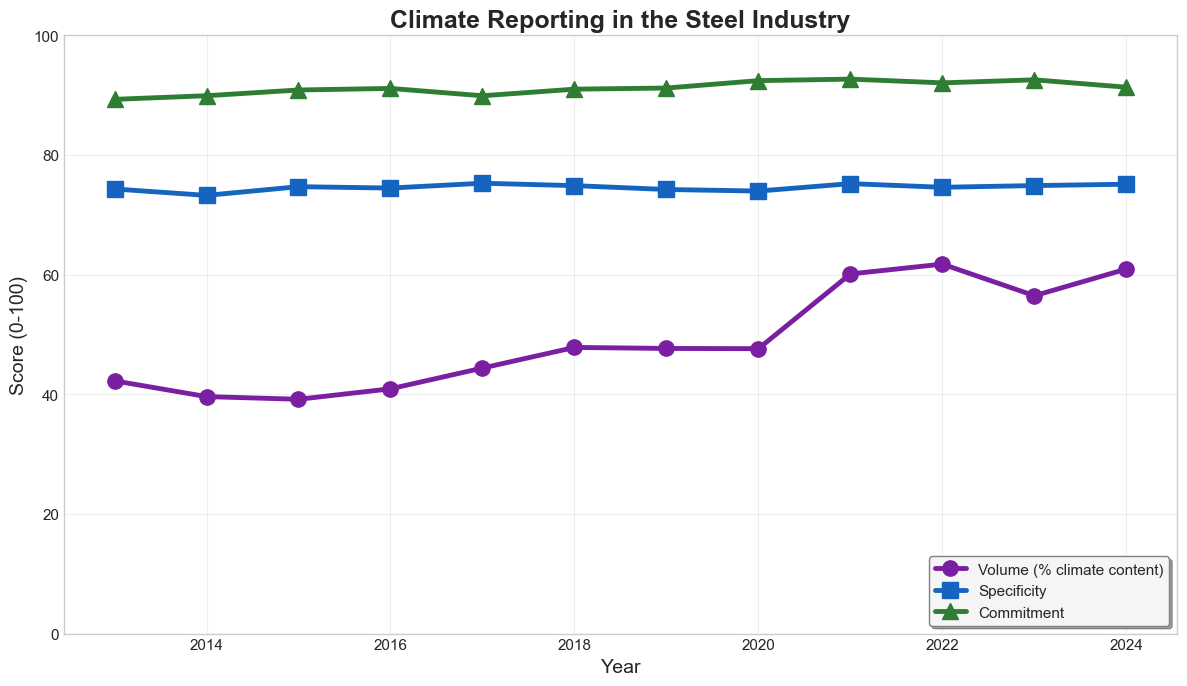

   ✓ slide_sentiment_trend.png


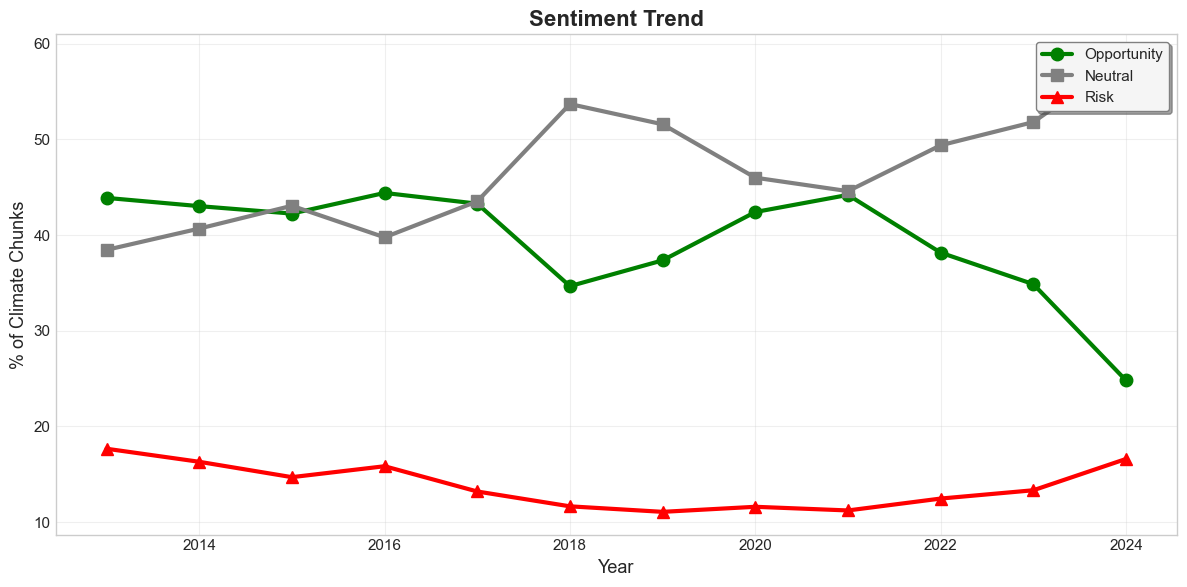

   ✓ talk_score_trend.png


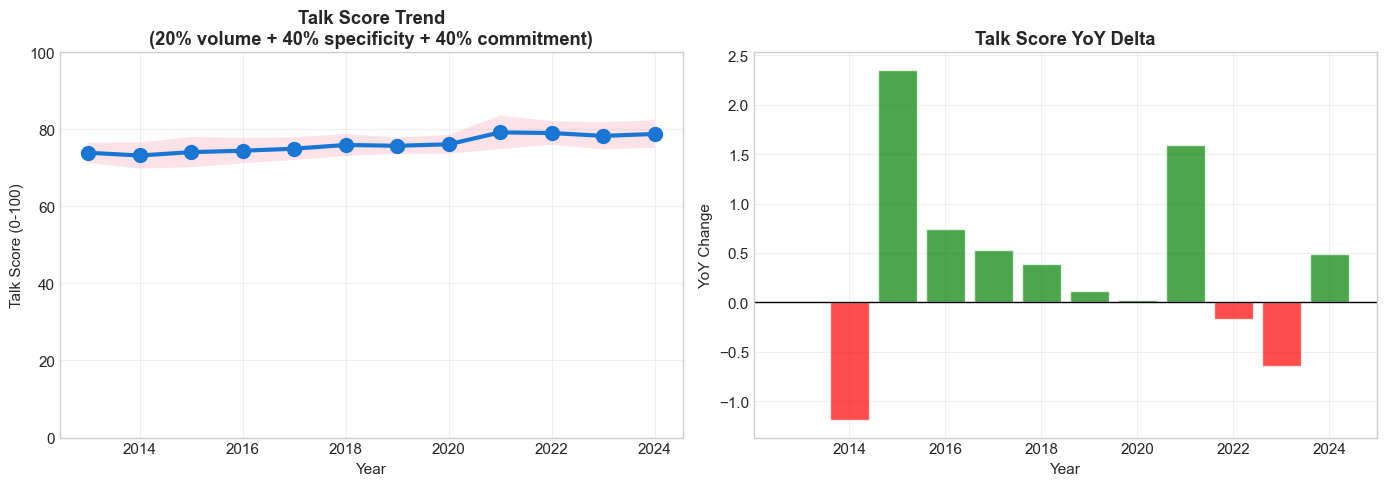

   ✓ talk_score_per_company.png


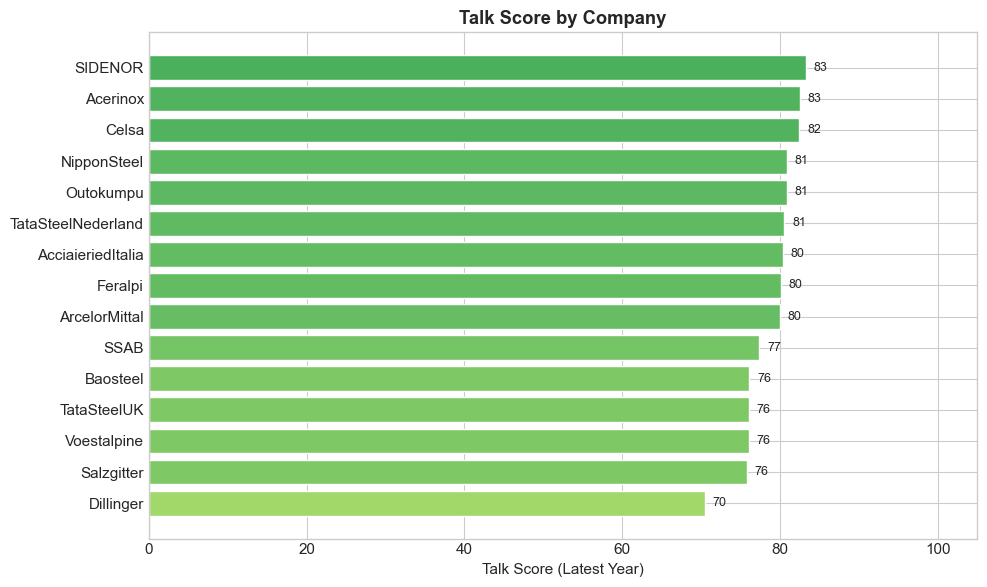

   ✓ per_company_components.png


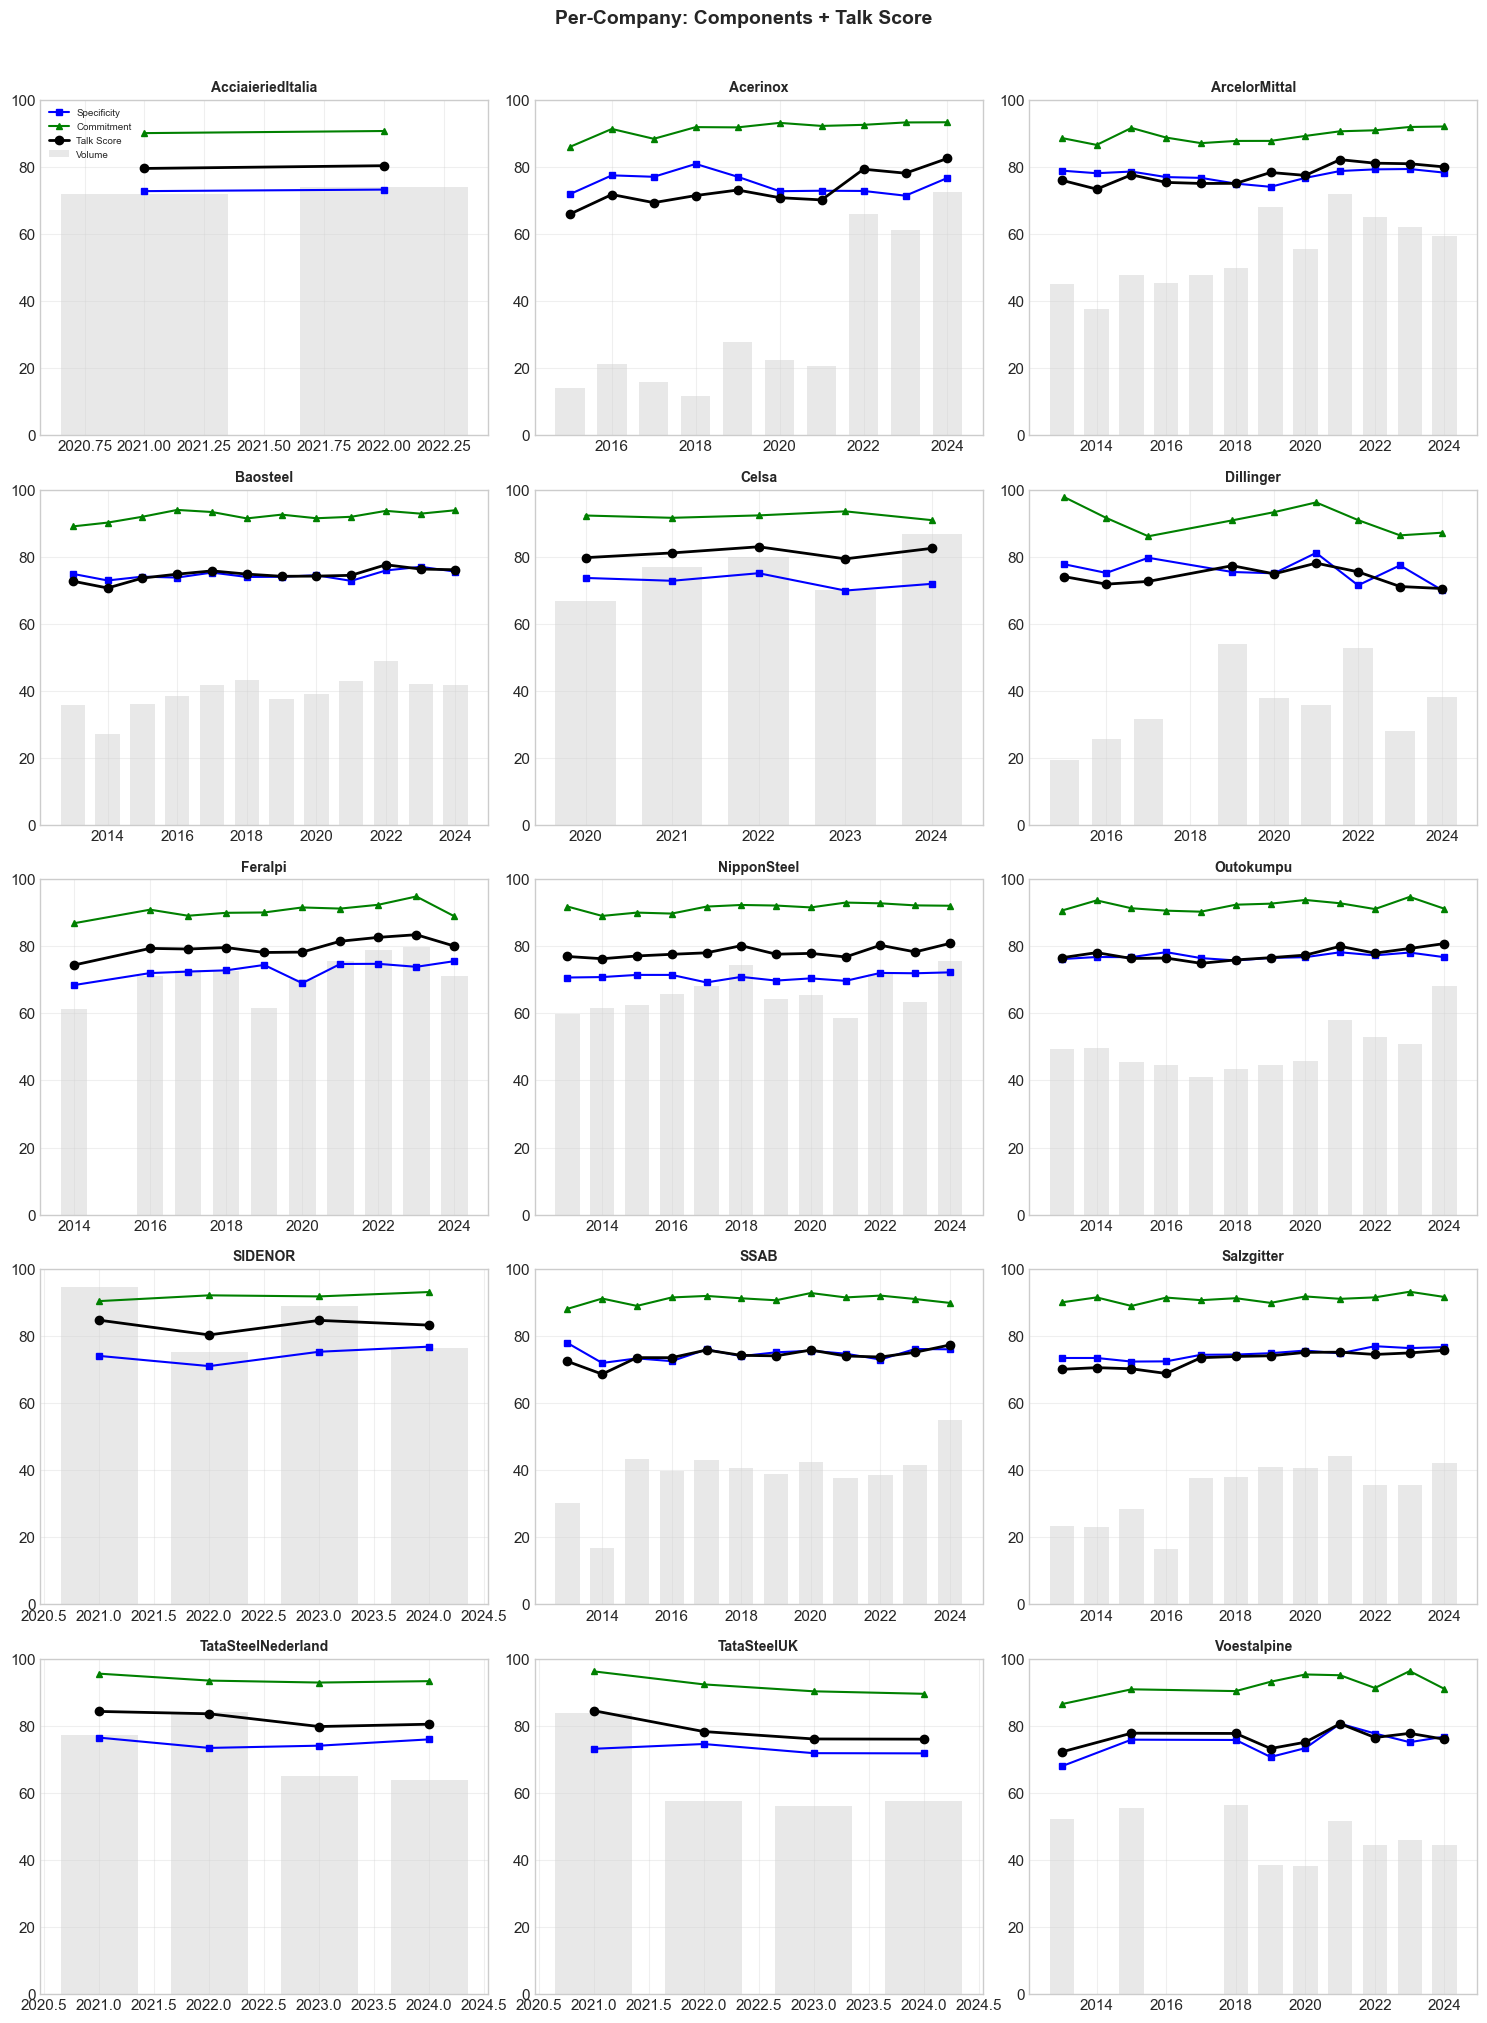

   ✓ per_company_sentiment.png


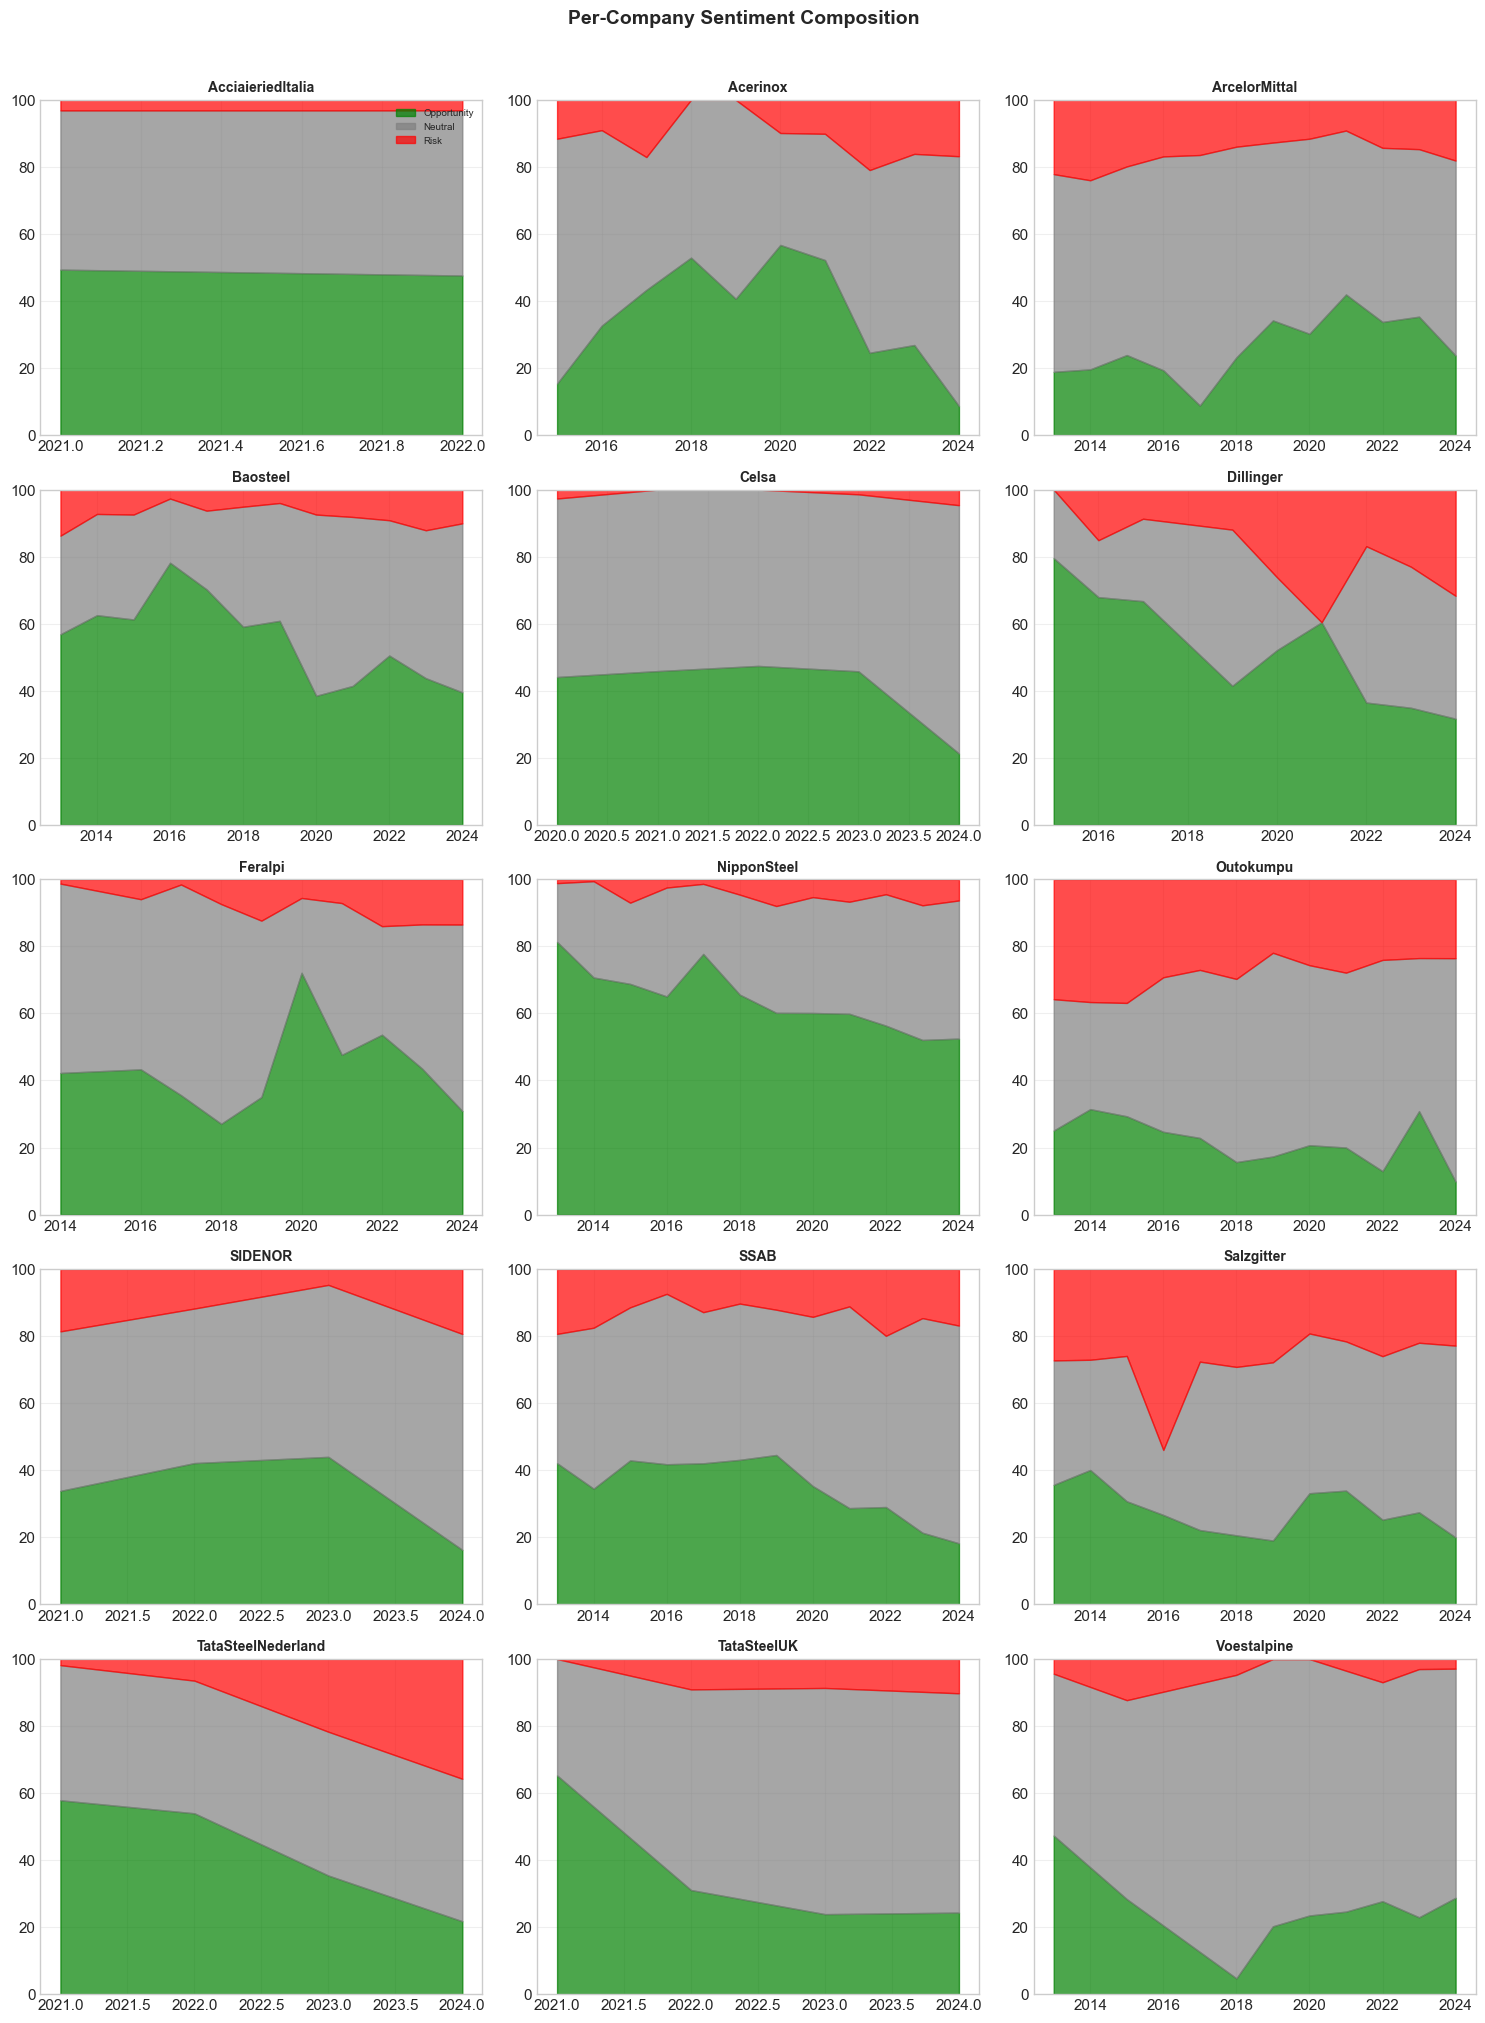

   ✓ sentiment_all_companies.png


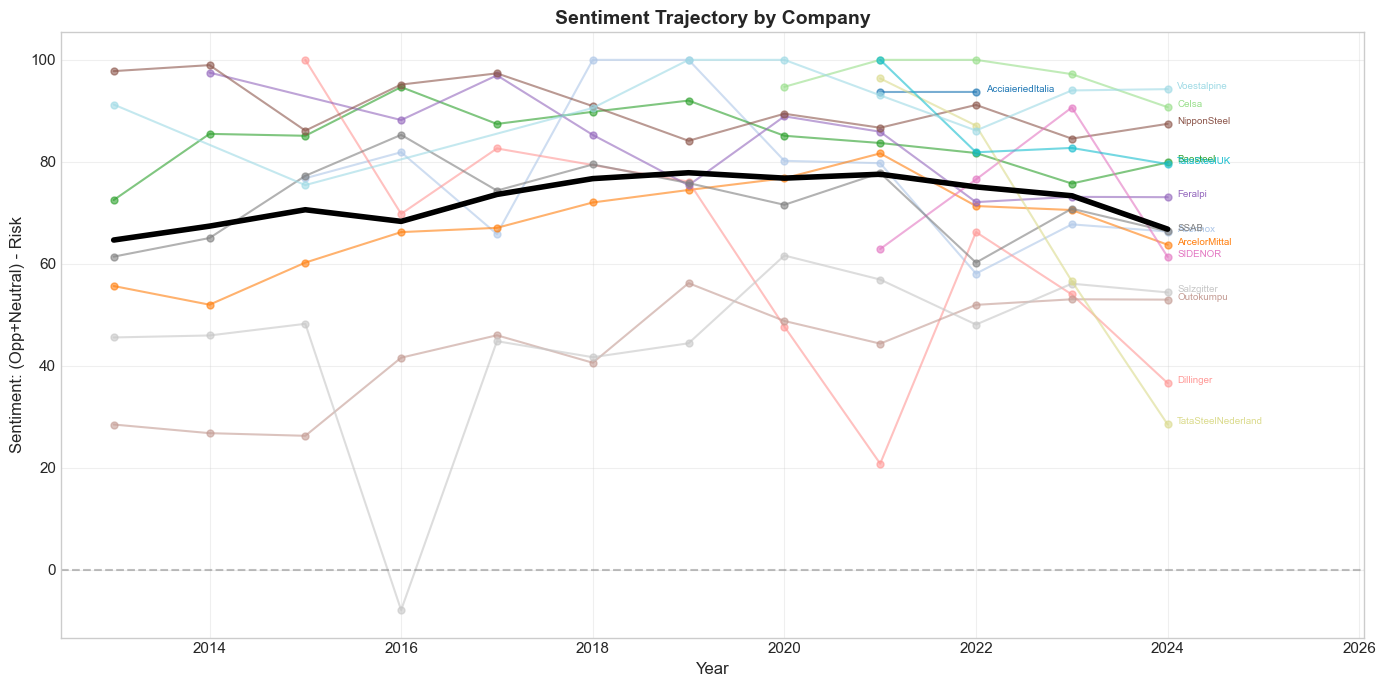


📊 SUMMARY FOR SLIDES
Data: 193 reports · 15,207 chunks · 15 companies · 2013-2024
Method: ClimateBERT (scores weighted by detector confidence)

Talk Score = 20% volume + 40% specificity + 40% commitment

Key Findings:
• Volume ↑ — more climate content in reports
• Quality → — specificity & commitment remain flat
• Sentiment shift: Opportunity → Neutral → Rising Risk

Loading chunk texts...
✅ Loaded 15,207 chunks
   Opportunity: 5,498
   Neutral: 7,118
   Risk: 2,591
   Commitment YES: 9,626
   Commitment NO: 5,581

TOP WORDS BY CATEGORY

📊 ALL CHUNKS (top 30):
environment(18134), sustainable(17493), production(17065), management(16472), product(14516), emission(14006), operation(13812), material(12365), risk(12286), energy(12048), development(12032), process(11966), financial(11688), business(11654), reduction(11173), supply(9577), million(9437), carbon(9152), iron(8384), value(7726), market(7657), price(7466), water(6984), governance(6866), technology(6725), strategy(6621), improve(6

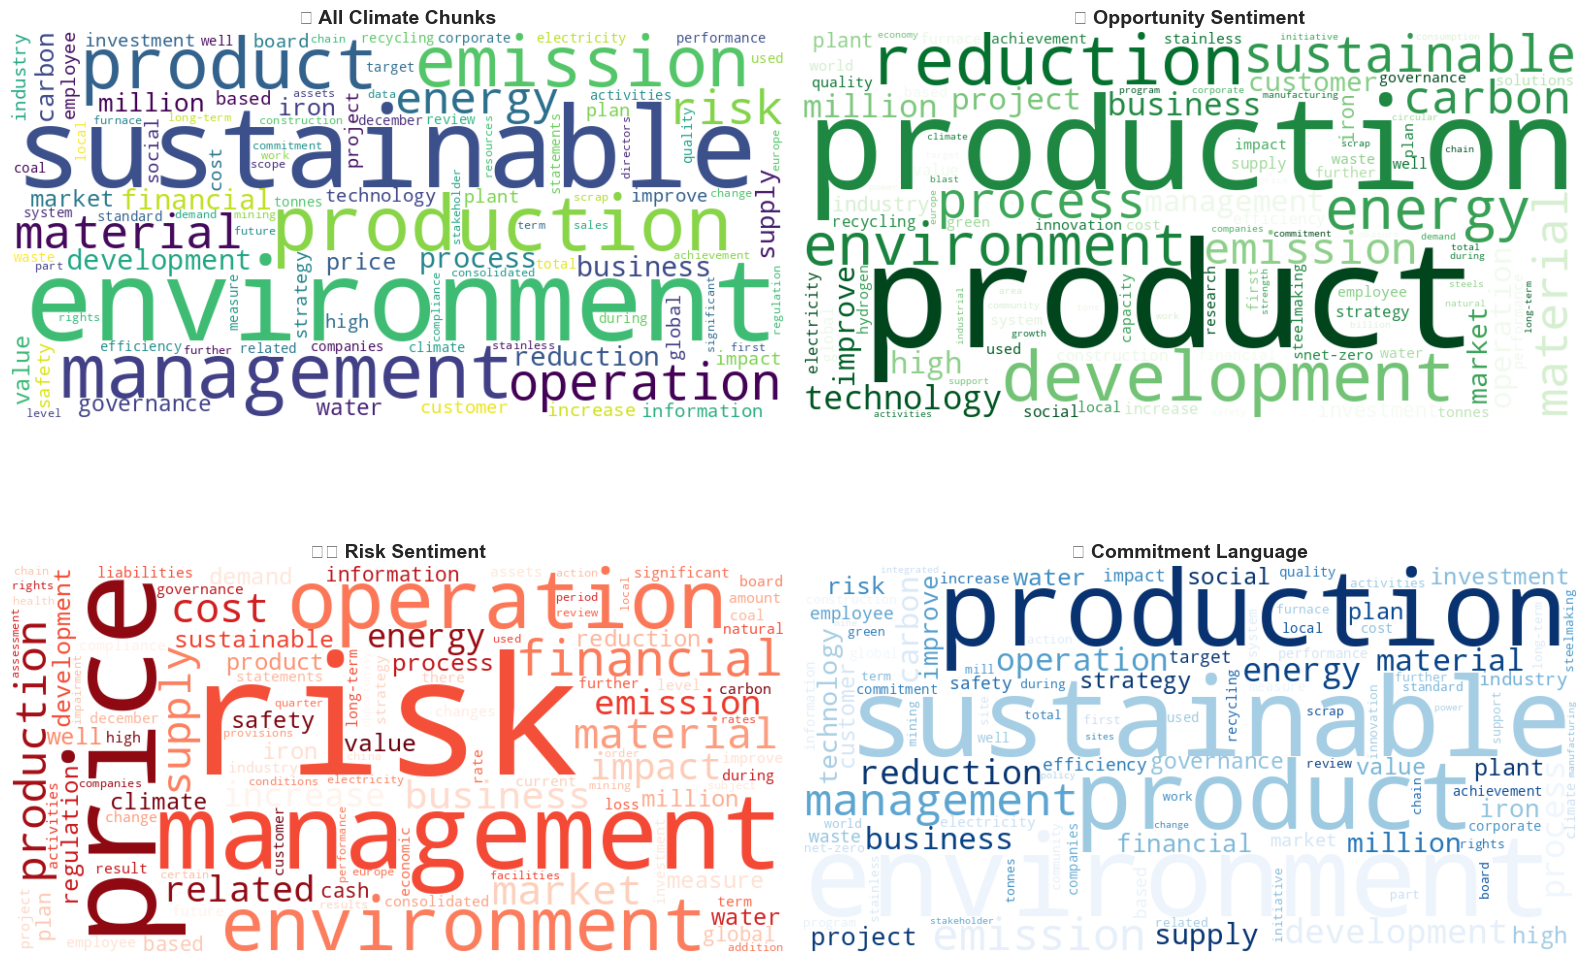

✅ Saved: word_frequencies.png


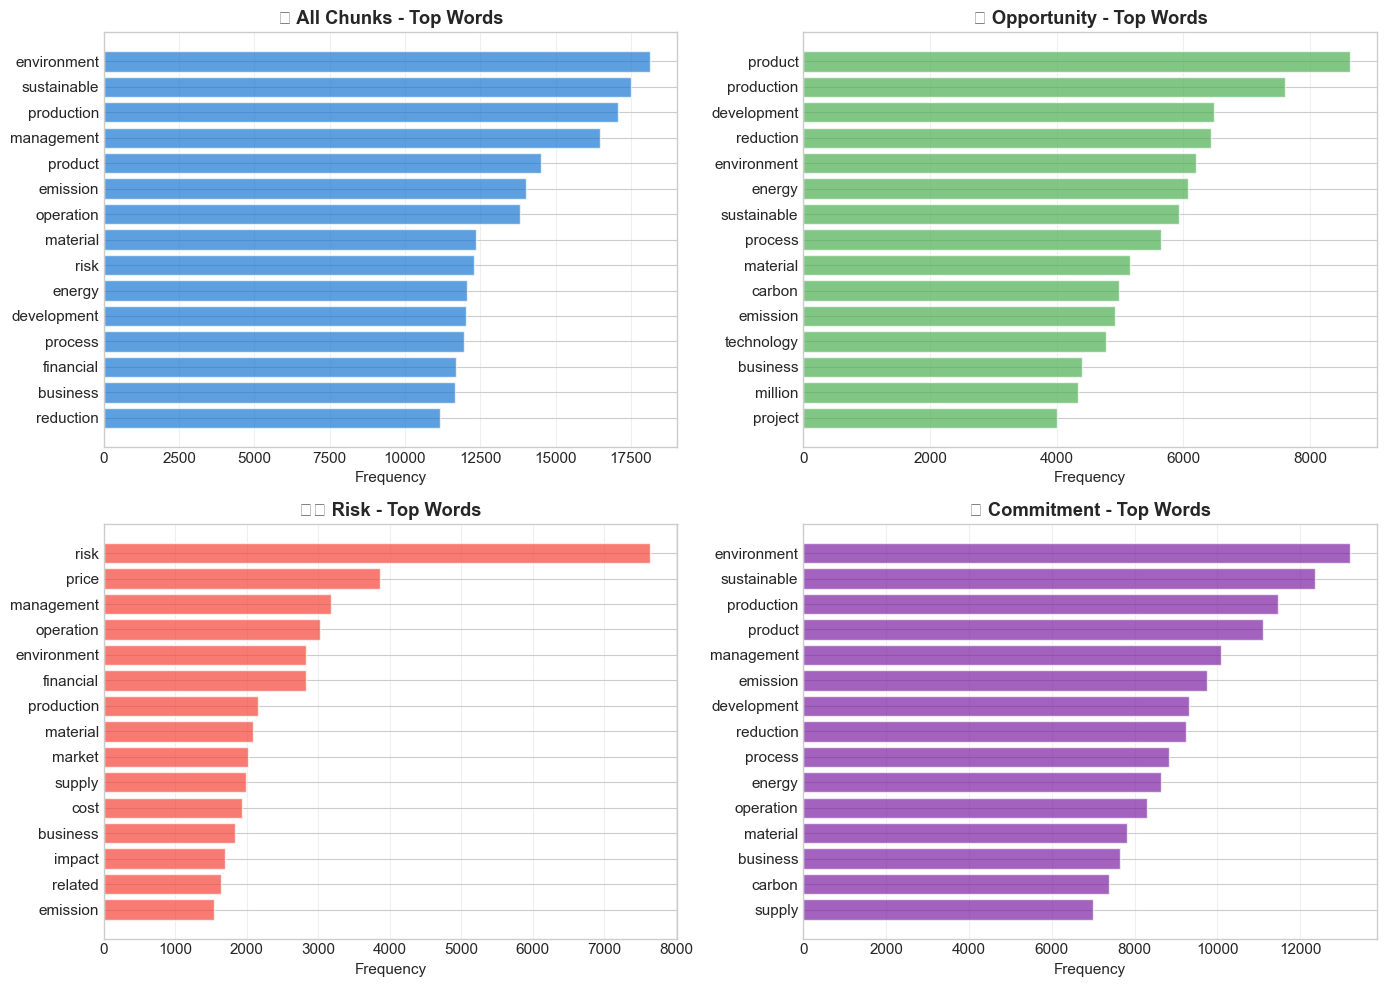

In [10]:
# =============================================================================
# STEEL INDUSTRY CLIMATE REPORT ANALYSIS - FINAL
# =============================================================================
#
# ## Overview
# Analyzes ~200 sustainability reports from European steel companies using
# ClimateBERT to extract climate discourse metrics.
#
# ## Metrics
# - **Volume**: % of report that is climate-related
# - **Specificity**: How concrete vs vague the claims are (0-100)
# - **Commitment**: How much action-oriented language (0-100)
# - **Talk Score**: Compound = 20% volume + 40% specificity + 40% commitment
# - **Sentiment**: Opportunity / Neutral / Risk framing
#
# ## Outputs
# - `slide_main.png`: Volume, Specificity, Commitment trends
# - `slide_sentiment_trend.png`: Sentiment over time
# - `talk_score_trend.png`: Talk score with YoY delta
# - `per_company_*.png`: Company-level breakdowns
#
# =============================================================================

# %% CELL 1: LOAD & PROCESS DATA
from collections import Counter
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# === CONFIG ===
DATA_DIR = './cache'
OUTPUT_DIR = './out'
EXCLUDE_PATTERNS = [
    'factsheet', 'fact_sheet',           # English
    'faktensheets', 'faktenblaetter',    # German plural
    'faktenblatt',                        # German singular
    'daten_und_fakten',                   # German "data and facts"
    'zahlen_und_fakten',                  # German "numbers and facts"
]
EXCLUDE_2025 = True  # Incomplete year

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

# --- Load bert.json files ---


def load_and_process():
    data_path = Path(DATA_DIR)
    bert_files = [f for f in data_path.glob('*_bert.json')
                  if not any(ex.lower() in f.name.lower() for ex in EXCLUDE_PATTERNS)]

    rows = []
    for fp in bert_files:
        try:
            with open(fp, 'r', encoding='utf-8') as f:
                data = json.load(f)
            chunks = data.get('chunks', [])
            if not chunks:
                continue

            n = len(chunks)
            detector = np.array([c.get('detector_score', 0) for c in chunks])
            weights = detector if detector.sum() > 0 else np.ones(n)

            spec_labels = [c.get('specificity_label', 'non') for c in chunks]
            sent_labels = [c.get('sentiment_label', 'neutral') for c in chunks]
            comm_labels = [c.get('commitment_label', 'no') for c in chunks]

            # Confidence-weighted sentiment percentages
            # Each chunk's sentiment vote is weighted by detector confidence
            opp_weights = sum(w for w, l in zip(
                weights, sent_labels) if l == 'opportunity')
            risk_weights = sum(w for w, l in zip(
                weights, sent_labels) if l == 'risk')
            neutral_weights = sum(w for w, l in zip(
                weights, sent_labels) if l == 'neutral')
            total_weights = weights.sum()

            rows.append({
                'company': data.get('company', 'Unknown'),
                'company_id': str(data.get('company_id', 'unknown')),
                'year': int(data.get('year', 0)),
                'is_translated': data.get('source', 'original') == 'translated',
                'climate_chunks': data.get('climate_chunks', n),
                'climate_pct': data.get('kept_percentage', 100.0),
                'specificity_w': np.average([c.get('specificity_score', 0) for c in chunks], weights=weights),
                'commitment_w': np.average([c.get('commitment_score', 0) for c in chunks], weights=weights),
                # Confidence-weighted sentiment percentages
                'opportunity_pct': (opp_weights / total_weights * 100) if total_weights > 0 else 0,
                'risk_pct': (risk_weights / total_weights * 100) if total_weights > 0 else 0,
                'neutral_pct': (neutral_weights / total_weights * 100) if total_weights > 0 else 0,
            })
        except:
            pass

    df = pd.DataFrame(rows)
    if EXCLUDE_2025:
        df = df[df['year'] < 2025]

    # Aggregate to company-year
    cy = df.groupby(['company_id', 'year']).agg({
        'company': 'first', 'is_translated': 'any', 'climate_chunks': 'sum',
        'climate_pct': 'mean', 'specificity_w': 'mean', 'commitment_w': 'mean',
        'opportunity_pct': 'mean', 'risk_pct': 'mean', 'neutral_pct': 'mean',
    }).reset_index()

    # Talk Score: 20% volume + 40% specificity + 40% commitment (quality-focused)
    cy['talk_score'] = ((cy['climate_pct']/100)*0.20 +
                        cy['specificity_w']*0.40 + cy['commitment_w']*0.40) * 100

    # Sentiment balances
    cy['sent_v1'] = cy['opportunity_pct'] - cy['risk_pct']
    cy['sent_v2'] = (cy['opportunity_pct'] +
                     cy['neutral_pct']) - cy['risk_pct']

    # YoY deltas
    cy = cy.sort_values(['company_id', 'year'])
    cy['talk_score_delta'] = cy.groupby('company_id')['talk_score'].diff()

    return df, cy


report_df, cy_df = load_and_process()
print(
    f"✅ Loaded: {len(report_df)} reports, {cy_df['company'].nunique()} companies, {cy_df['year'].min()}-{cy_df['year'].max()}")

# %% CELL 2: ALL PLOTS


def save(name):
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{name}', dpi=200, bbox_inches='tight')
    print(f"   ✓ {name}")
    plt.show()


yearly = cy_df.groupby('year').agg({
    'climate_pct': 'mean', 'specificity_w': 'mean', 'commitment_w': 'mean',
    'talk_score': ['mean', 'std'], 'talk_score_delta': 'mean',
    'opportunity_pct': 'mean', 'risk_pct': 'mean', 'neutral_pct': 'mean',
    'company_id': 'nunique',
}).reset_index()
yearly.columns = ['year', 'volume', 'specificity', 'commitment', 'talk_mean', 'talk_std',
                  'talk_delta', 'opp', 'risk', 'neutral', 'n_companies']

# === 1. MAIN SLIDE: Volume, Specificity, Commitment ===
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(yearly['year'], yearly['volume'], '#7B1FA2', lw=3.5,
        marker='o', ms=11, label='Volume (% climate content)')
ax.plot(yearly['year'], yearly['specificity']*100, '#1565C0',
        lw=3.5, marker='s', ms=11, label='Specificity')
ax.plot(yearly['year'], yearly['commitment']*100, '#2E7D32',
        lw=3.5, marker='^', ms=11, label='Commitment')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Score (0-100)', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.set_title('Climate Reporting in the Steel Industry',
             fontsize=18, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, frameon=True, fancybox=True,
          shadow=True, facecolor='#F5F5F5', edgecolor='gray')
save('slide_main.png')

# === 2. SENTIMENT TREND (Separate Lines) ===
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly['year'], yearly['opp'], 'g-o', lw=3, ms=9, label='Opportunity')
ax.plot(yearly['year'], yearly['neutral'], 'gray',
        ls='-', marker='s', lw=3, ms=9, label='Neutral')
ax.plot(yearly['year'], yearly['risk'], 'r-^', lw=3, ms=9, label='Risk')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('% of Climate Chunks', fontsize=13)
ax.set_title('Sentiment Trend', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True,
          shadow=True, facecolor='#F5F5F5', edgecolor='gray')
save('slide_sentiment_trend.png')

# === 3. TALK SCORE TREND + DELTA ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.plot(yearly['year'], yearly['talk_mean'],
         '#1976D2', lw=3, marker='o', ms=10)
ax1.fill_between(yearly['year'], yearly['talk_mean']-yearly['talk_std'],
                 yearly['talk_mean']+yearly['talk_std'], alpha=0.2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Talk Score (0-100)')
ax1.set_title(
    'Talk Score Trend\n(20% volume + 40% specificity + 40% commitment)', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
colors = ['green' if d > 0 else 'red' for d in yearly['talk_delta'].fillna(0)]
ax2.bar(yearly['year'], yearly['talk_delta'].fillna(
    0), color=colors, alpha=0.7, edgecolor='white')
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel('Year')
ax2.set_ylabel('YoY Change')
ax2.set_title('Talk Score YoY Delta', fontweight='bold')
ax2.grid(True, alpha=0.3)
save('talk_score_trend.png')

# === 4. TALK SCORE PER COMPANY ===
company_stats = cy_df.groupby('company').agg({'talk_score': [
    'mean', 'last'], 'talk_score_delta': 'mean', 'year': 'count'}).reset_index()
company_stats.columns = ['company', 'talk_mean',
                         'talk_latest', 'talk_delta_avg', 'n_years']
company_stats = company_stats.sort_values('talk_latest')

fig, ax = plt.subplots(figsize=(10, max(6, len(company_stats)*0.4)))
colors = plt.cm.RdYlGn(company_stats['talk_latest']/100)
ax.barh(company_stats['company'], company_stats['talk_latest'],
        color=colors, edgecolor='white')
for i, (_, r) in enumerate(company_stats.iterrows()):
    ax.text(r['talk_latest']+1, i,
            f'{r["talk_latest"]:.0f}', va='center', fontsize=9)
ax.set_xlabel('Talk Score (Latest Year)')
ax.set_xlim(0, 105)
ax.set_title('Talk Score by Company', fontweight='bold')
save('talk_score_per_company.png')

# === 5. PER-COMPANY: Volume, Specificity, Commitment + Talk Score ===
companies = sorted(cy_df['company'].unique())
n_cols, n_rows = 3, int(np.ceil(len(companies)/3))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(
    5*n_cols, 4*n_rows), squeeze=False)
axes = axes.flatten()

for i, company in enumerate(companies):
    ax = axes[i]
    cd = cy_df[cy_df['company'] == company].sort_values('year')
    ax.bar(cd['year'], cd['climate_pct'], color='lightgray',
           alpha=0.5, label='Volume', width=0.7)
    ax.plot(cd['year'], cd['specificity_w']*100,
            'b-s', ms=5, lw=1.5, label='Specificity')
    ax.plot(cd['year'], cd['commitment_w']*100,
            'g-^', ms=5, lw=1.5, label='Commitment')
    ax.plot(cd['year'], cd['talk_score'], 'k-o',
            ms=6, lw=2, label='Talk Score')
    ax.set_title(company, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Per-Company: Components + Talk Score',
             fontsize=14, fontweight='bold', y=1.01)
save('per_company_components.png')

# === 6. PER-COMPANY SENTIMENT (STACKED AREA) ===
fig, axes = plt.subplots(n_rows, n_cols, figsize=(
    5*n_cols, 4*n_rows), squeeze=False)
axes = axes.flatten()

for i, company in enumerate(companies):
    ax = axes[i]
    cd = cy_df[cy_df['company'] == company].sort_values('year')

    # Stacked area: Opportunity (bottom), Neutral (middle), Risk (top)
    ax.fill_between(cd['year'], 0, cd['opportunity_pct'],
                    color='green', alpha=0.7, label='Opportunity')
    ax.fill_between(cd['year'], cd['opportunity_pct'], cd['opportunity_pct']+cd['neutral_pct'],
                    color='gray', alpha=0.7, label='Neutral')
    ax.fill_between(cd['year'], cd['opportunity_pct']+cd['neutral_pct'], 100,
                    color='red', alpha=0.7, label='Risk')

    ax.set_title(company, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Per-Company Sentiment Composition',
             fontsize=14, fontweight='bold', y=1.01)
save('per_company_sentiment.png')

# === 7. ALL COMPANIES SENTIMENT TRAJECTORY ===
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(companies)))
for i, company in enumerate(companies):
    cd = cy_df[cy_df['company'] == company].sort_values('year')
    ax.plot(cd['year'], cd['sent_v2'], '-o',
            color=colors[i], lw=1.5, ms=5, alpha=0.6)
    if len(cd) > 0:
        ax.annotate(company, (cd['year'].iloc[-1]+0.1,
                    cd['sent_v2'].iloc[-1]), fontsize=7, color=colors[i])
# Industry average
yearly_sent = cy_df.groupby('year')['sent_v2'].mean()
ax.plot(yearly_sent.index, yearly_sent.values,
        'k-', lw=4, label='Industry Avg', zorder=10)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sentiment: (Opp+Neutral) - Risk', fontsize=12)
ax.set_title('Sentiment Trajectory by Company', fontsize=14, fontweight='bold')
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1]+1.5)
ax.grid(True, alpha=0.3)
save('sentiment_all_companies.png')

# === SUMMARY STATS ===
n_reports = len(report_df)
n_chunks = int(cy_df['climate_chunks'].sum())
n_companies = cy_df['company'].nunique()
year_range = f"{cy_df['year'].min()}-{cy_df['year'].max()}"

print(f"""
{'='*60}
📊 SUMMARY FOR SLIDES
{'='*60}
Data: {n_reports} reports · {n_chunks:,} chunks · {n_companies} companies · {year_range}
Method: ClimateBERT (scores weighted by detector confidence)

Talk Score = 20% volume + 40% specificity + 40% commitment

Key Findings:
• Volume ↑ — more climate content in reports
• Quality → — specificity & commitment remain flat
• Sentiment shift: Opportunity → Neutral → Rising Risk
{'='*60}
""")

# %% CELL 3: WORD CLOUD & FREQUENCY ANALYSIS
# Requires: pip install wordcloud
# Run this cell separately - it reloads chunk text from files


def load_all_chunk_texts():
    """Load all chunk texts from bert.json files."""
    data_path = Path(DATA_DIR)
    bert_files = [f for f in data_path.glob('*_bert.json')
                  if not any(ex.lower() in f.name.lower() for ex in EXCLUDE_PATTERNS)]

    all_texts = []
    texts_by_sentiment = {'opportunity': [], 'risk': [], 'neutral': []}
    texts_by_commitment = {'yes': [], 'no': []}

    for fp in bert_files:
        try:
            with open(fp, 'r', encoding='utf-8') as f:
                data = json.load(f)

            year = data.get('year', 0)
            if EXCLUDE_2025 and year >= 2025:
                continue

            for chunk in data.get('chunks', []):
                text = chunk.get('text', '')
                if text:
                    all_texts.append(text)

                    # Group by sentiment
                    sent = chunk.get('sentiment_label', 'neutral')
                    if sent in texts_by_sentiment:
                        texts_by_sentiment[sent].append(text)

                    # Group by commitment
                    comm = chunk.get('commitment_label', 'no')
                    if comm in texts_by_commitment:
                        texts_by_commitment[comm].append(text)
        except:
            pass

    return all_texts, texts_by_sentiment, texts_by_commitment


def get_word_frequencies(texts, min_word_len=4, top_n=50):
    """Get word frequencies with grouping under readable representative words."""
    # Common stopwords to exclude
    stopwords = {
        # English stopwords
        'the', 'and', 'for', 'that', 'with', 'are', 'from', 'this', 'was', 'were',
        'been', 'have', 'has', 'will', 'would', 'could', 'should', 'their', 'they',
        'which', 'what', 'when', 'where', 'who', 'how', 'our', 'your', 'more', 'also',
        'than', 'into', 'over', 'such', 'through', 'being', 'between', 'after', 'before',
        'these', 'those', 'other', 'some', 'most', 'about', 'including', 'within',
        # Domain words
        'steel', 'company', 'group', 'year', 'years', 'report', 'reporting', 'annual',
        # Company names (lowercase)
        'arcelormittal', 'arcelor', 'mittal', 'thyssenkrupp', 'thyssen', 'krupp',
        'voestalpine', 'salzgitter', 'ssab', 'outokumpu', 'tata', 'tatasteel',
        'nippon', 'nipponsteeel', 'baosteel', 'baoshan', 'posco', 'nucor',
        'acerinox', 'celsa', 'dillinger', 'sidenor', 'feralpi', 'arvedi',
        'acciaierieditalia', 'acciaieri', 'italia', 'nederland', 'tatasteelnederland',
        'tatasteeluk', 'tatasteeleurope',
    }

    # Word groups: map variants to a single readable representative
    # Key = representative word, Values = all variants that should count as this word
    word_groups = {
        'emission': ['emission', 'emissions', 'emitting', 'emitted', 'emit'],
        'carbon': ['carbon', 'carbons', 'co2', 'dioxide'],
        'energy': ['energy', 'energies', 'energetic'],
        'sustainable': ['sustainable', 'sustainability', 'sustainably'],
        'environment': ['environment', 'environmental', 'environmentally', 'environments'],
        'climate': ['climate', 'climatic', 'climates'],
        'reduction': ['reduction', 'reductions', 'reduce', 'reduced', 'reducing', 'reduces'],
        'target': ['target', 'targets', 'targeted', 'targeting'],
        'goal': ['goal', 'goals'],
        'commitment': ['commitment', 'commitments', 'commit', 'commits', 'committed', 'committing'],
        'production': ['production', 'productions', 'produce', 'produced', 'producing', 'produces', 'productive'],
        'price': ['price','prices'],
        'process': ['process', 'processes', 'processing', 'processed'],
        'technology': ['technology', 'technologies', 'technological', 'tech'],
        'innovation': ['innovation', 'innovations', 'innovative', 'innovate', 'innovating'],
        'investment': ['investment', 'investments', 'invest', 'invested', 'investing', 'investor', 'investors'],
        'development': ['development', 'developments', 'develop', 'developed', 'developing', 'develops'],
        'strategy': ['strategy', 'strategies', 'strategic', 'strategically'],
        'management': ['management', 'manage', 'managed', 'managing', 'manager', 'managers'],
        'performance': ['performance', 'performances', 'perform', 'performed', 'performing'],
        'business': ['business', 'businesses'],
        'operation': ['operation', 'operations', 'operate', 'operated', 'operating', 'operational'],
        'employee': ['employee', 'employees', 'employment', 'employer', 'employers'],
        'safety': ['safety', 'safe', 'safely', 'safer'],
        'risk': ['risk', 'risks', 'risky'],
        'opportunity': ['opportunity', 'opportunities'],
        'challenge': ['challenge', 'challenges', 'challenging', 'challenged'],
        'impact': ['impact', 'impacts', 'impacted', 'impacting'],
        'measure': ['measure', 'measures', 'measured', 'measuring', 'measurement', 'measurements'],
        'improve': ['improve', 'improved', 'improving', 'improvement', 'improvements'],
        'increase': ['increase', 'increased', 'increasing', 'increases'],
        'decrease': ['decrease', 'decreased', 'decreasing', 'decreases'],
        'efficiency': ['efficiency', 'efficient', 'efficiently', 'efficiencies'],
        'renewable': ['renewable', 'renewables', 'renew', 'renewed'],
        'electricity': ['electricity', 'electric', 'electrical', 'electrification'],
        'hydrogen': ['hydrogen'],
        'natural': ['natural', 'naturally', 'nature'],
        'gas': ['gas', 'gases', 'gaseous'],
        'water': ['water', 'waters', 'wastewater'],
        'waste': ['waste', 'wastes', 'wasted', 'wasting'],
        'recycling': ['recycling', 'recycle', 'recycled', 'recyclable'],
        'circular': ['circular', 'circularity'],
        'supply': ['supply', 'supplies', 'supplier', 'suppliers', 'supplying'],
        'chain': ['chain', 'chains'],
        'material': ['material', 'materials', 'raw'],
        'product': ['product', 'products'],
        'customer': ['customer', 'customers'],
        'market': ['market', 'markets', 'marketing'],
        'global': ['global', 'globally', 'globe'],
        'local': ['local', 'locally', 'location', 'locations'],
        'community': ['community', 'communities'],
        'social': ['social', 'socially', 'society', 'societies'],
        'governance': ['governance', 'govern', 'governing', 'government'],
        'compliance': ['compliance', 'comply', 'compliant', 'complying'],
        'regulation': ['regulation', 'regulations', 'regulatory', 'regulate', 'regulated'],
        'standard': ['standard', 'standards', 'standardized'],
        'certification': ['certification', 'certifications', 'certified', 'certify'],
        'initiative': ['initiative', 'initiatives'],
        'project': ['project', 'projects'],
        'program': ['program', 'programs', 'programme', 'programmes'],
        'action': ['action', 'actions'],
        'plan': ['plan', 'plans', 'planned', 'planning'],
        'future': ['future', 'futures'],
        'long-term': ['longterm', 'long'],
        'short-term': ['shortterm', 'short'],
        'transition': ['transition', 'transitions', 'transitioning'],
        'transformation': ['transformation', 'transformations', 'transform', 'transforming'],
        'decarbonization': ['decarbonization', 'decarbonisation', 'decarbonize', 'decarbonise'],
        'net-zero': ['netzero', 'zero', 'neutrality', 'neutral'],
        'scope': ['scope', 'scopes'],
        'footprint': ['footprint', 'footprints'],
        'intensity': ['intensity', 'intensive', 'intensities'],
        'absolute': ['absolute', 'absolutely'],
        'baseline': ['baseline', 'baselines'],
        'pathway': ['pathway', 'pathways', 'path'],
        'roadmap': ['roadmap', 'roadmaps'],
        'milestone': ['milestone', 'milestones'],
        'progress': ['progress', 'progressing', 'progressed'],
        'achievement': ['achievement', 'achievements', 'achieve', 'achieved', 'achieving'],
        'success': ['success', 'successful', 'successfully', 'successes'],
        'value': ['value', 'values', 'valuable', 'valuation'],
        'cost': ['cost', 'costs', 'costly'],
        'benefit': ['benefit', 'benefits', 'beneficial'],
        'stakeholder': ['stakeholder', 'stakeholders'],
        'shareholder': ['shareholder', 'shareholders'],
        'partner': ['partner', 'partners', 'partnership', 'partnerships'],
        'collaboration': ['collaboration', 'collaborations', 'collaborate', 'collaborative'],
        'research': ['research', 'researching', 'researcher', 'researchers'],
        'science': ['science', 'scientific', 'scientist', 'scientists', 'sciencebased'],
    }

    # Create reverse lookup: variant -> representative
    variant_to_rep = {}
    for rep, variants in word_groups.items():
        for v in variants:
            variant_to_rep[v] = rep

    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
        for w in words:
            if len(w) >= min_word_len and w not in stopwords:
                # Map to representative word if in a group, otherwise keep original
                all_words.append(variant_to_rep.get(w, w))

    return Counter(all_words).most_common(top_n)



# Load texts
print("Loading chunk texts...")
all_texts, texts_by_sentiment, texts_by_commitment = load_all_chunk_texts()
print(f"✅ Loaded {len(all_texts):,} chunks")
print(f"   Opportunity: {len(texts_by_sentiment['opportunity']):,}")
print(f"   Neutral: {len(texts_by_sentiment['neutral']):,}")
print(f"   Risk: {len(texts_by_sentiment['risk']):,}")
print(f"   Commitment YES: {len(texts_by_commitment['yes']):,}")
print(f"   Commitment NO: {len(texts_by_commitment['no']):,}")

# === WORD FREQUENCY ANALYSIS ===
print("\n" + "="*60)
print("TOP WORDS BY CATEGORY")
print("="*60)

freq_all = get_word_frequencies(all_texts, top_n=30)
freq_opp = get_word_frequencies(texts_by_sentiment['opportunity'], top_n=20)
freq_risk = get_word_frequencies(texts_by_sentiment['risk'], top_n=20)
freq_commit = get_word_frequencies(texts_by_commitment['yes'], top_n=20)

print("\n📊 ALL CHUNKS (top 30):")
print(", ".join([f"{w}({c})" for w, c in freq_all]))

print("\n🌱 OPPORTUNITY chunks (top 20):")
print(", ".join([f"{w}({c})" for w, c in freq_opp]))

print("\n⚠️ RISK chunks (top 20):")
print(", ".join([f"{w}({c})" for w, c in freq_risk]))

print("\n🤝 COMMITMENT chunks (top 20):")
print(", ".join([f"{w}({c})" for w, c in freq_commit]))

# === WORD CLOUD ===
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    def make_cloud(ax, texts, title, colormap='viridis'):
        freq = get_word_frequencies(texts, top_n=100)
        if freq:
            wc = WordCloud(width=800, height=400, background_color='white',
                           colormap=colormap, max_words=100)
            wc.generate_from_frequencies(dict(freq))
            ax.imshow(wc, interpolation='bilinear')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')

    make_cloud(axes[0, 0], all_texts, '📊 All Climate Chunks', 'viridis')
    make_cloud(axes[0, 1], texts_by_sentiment['opportunity'],
               '🌱 Opportunity Sentiment', 'Greens')
    make_cloud(axes[1, 0], texts_by_sentiment['risk'],
               '⚠️ Risk Sentiment', 'Reds')
    make_cloud(axes[1, 1], texts_by_commitment['yes'],
               '🤝 Commitment Language', 'Blues')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/wordclouds.png', dpi=150, bbox_inches='tight')
    print(f"\n✅ Saved: wordclouds.png")
    plt.show()

except ImportError:
    print("\n⚠️ wordcloud not installed. Run: pip install wordcloud")

# === FREQUENCY BAR CHART (alternative to word cloud) ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


def plot_freq_bars(ax, freqs, title, color):
    words, counts = zip(*freqs[:15]) if freqs else ([], [])
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=color, alpha=0.7, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')


plot_freq_bars(axes[0, 0], freq_all[:15],
               '📊 All Chunks - Top Words', '#1976D2')
plot_freq_bars(axes[0, 1], freq_opp[:15],
               '🌱 Opportunity - Top Words', '#4CAF50')
plot_freq_bars(axes[1, 0], freq_risk[:15], '⚠️ Risk - Top Words', '#F44336')
plot_freq_bars(axes[1, 1], freq_commit[:15],
               '🤝 Commitment - Top Words', '#7B1FA2')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/word_frequencies.png', dpi=150, bbox_inches='tight')
print(f"✅ Saved: word_frequencies.png")
plt.show()